In [ ]:
from micrograd.engine import Value

a = Value(-4.0)
b = Value(2.0)
c = a + b
d = a * b + b**3
c += c + 1
c += 1 + c + (-a)
d += d * 2 + (b + a).relu()
d += 3 * d + (b - a).relu()
e = c - d
f = e**2
g = f / 2.0
g += 10.0 / f
print(f'{g.data:.4f}') # prints 24.7041, the outcome of this forward pass
g.backward()
print(f'{a.grad:.4f}') # prints 138.8338, i.e. the numerical value of dg/da
print(f'{b.grad:.4f}') # prints 645.5773, i.e. the numerical value of dg/db

24.7041
138.8338
645.5773


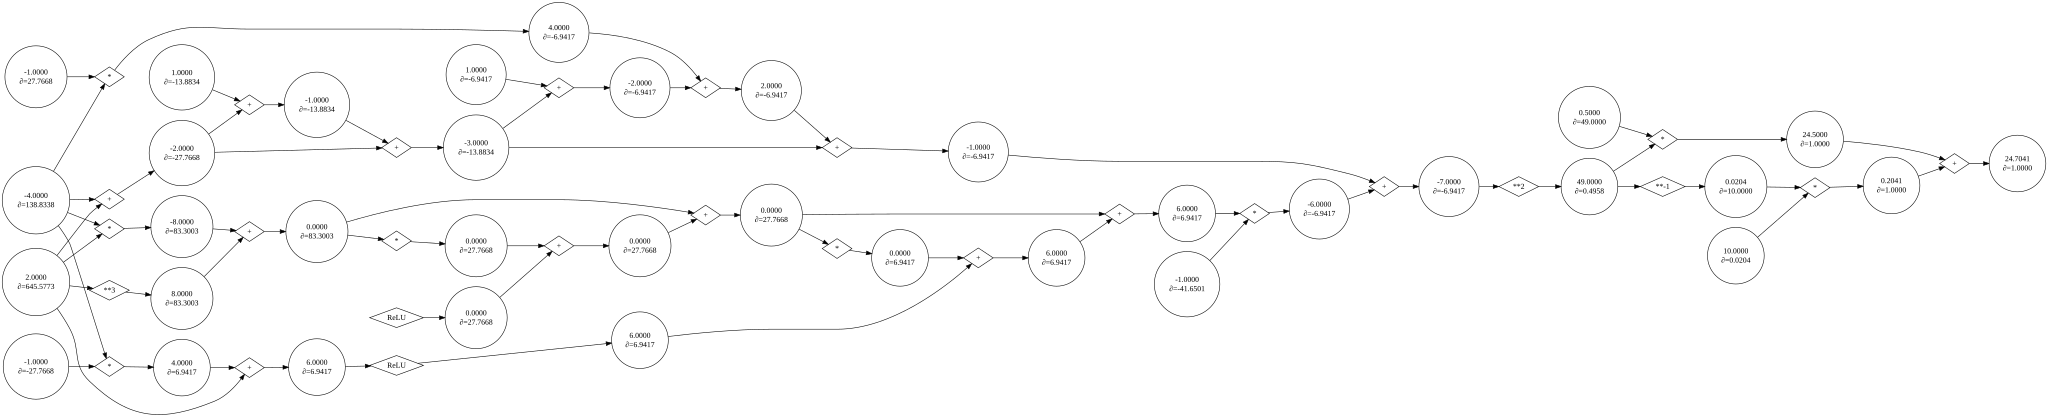

In [3]:
def draw_dot_simplified(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) 
    nodes, edges = trace(root)
    for n in nodes:
        if n.grad != 0:  # Only include nodes with non-zero gradients
            uid = str(id(n))
            dot.node(name=uid, label=f"{n.data:.4f}\n∂={n.grad:.4f}", shape='circle')
            if n._op:
                dot.node(name=uid + n._op, label=n._op, shape='diamond')
                dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        if n1.grad != 0 and n2.grad != 0:  # Only include edges between relevant nodes
            dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

draw_dot_simplified(g)
